In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import math
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv')

# View the first few rows
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [3]:
x_train = df[['YearsExperience']].to_numpy()
y_train = df['Salary'].to_numpy()
#they are now numpy arrays x is 2D and y is 1D'

In [4]:
def cost(x, y, w, b):
    m = x.shape[0]
    total_cost = 0
    for i in range(m):
        f_wb = w * x[i, 0] + b 
        total_cost += (f_wb - y[i]) ** 2

    total_cost = total_cost / (2 * m)
    return total_cost

def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        prdction = w * x[i, 0] + b
        dj_dw += (prdction - y[i]) * x[i, 0]
        dj_db += prdction - y[i]
        
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    return dj_dw, dj_db

In [5]:
def gradient_descent(w_in, b_in, x, y, alpha, num_iters):
    J_hist = []
    w_hist = []
    dw = 0
    db = 0
    current_cost = 0
    for i in range(num_iters):
        dw, db = compute_gradient(x, y, w_in, b_in)
        w_in -= alpha * dw
        b_in -= alpha * db

        if i%math.ceil(num_iters/10) == 0:
            current_cost = cost(x, y, w_in, b_in)
            J_hist.append(current_cost)
            w_hist.append(w_in)
            print(f"Iteration: {i}  cost: {current_cost}")
    return w_in, b_in, J_hist, w_hist

Iteration: 0  cost: 1152815708.165674
Iteration: 100  cost: 50686222.45935067
Iteration: 200  cost: 37926487.453284174
Iteration: 300  cost: 29811755.85588554
Iteration: 400  cost: 24651079.018434517
Iteration: 500  cost: 21369074.54287787
Iteration: 600  cost: 19281837.98130811
Iteration: 700  cost: 17954430.753073134
Iteration: 800  cost: 17110247.596255776
Iteration: 900  cost: 16573377.533252051
found in grad descent | weight: 9800.622916473048 bias: 22458.972436147695 


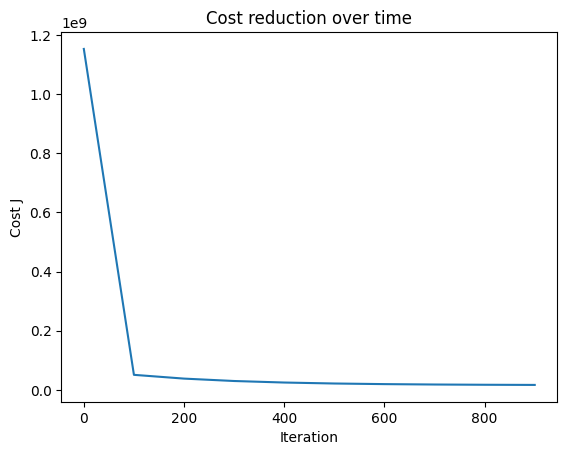

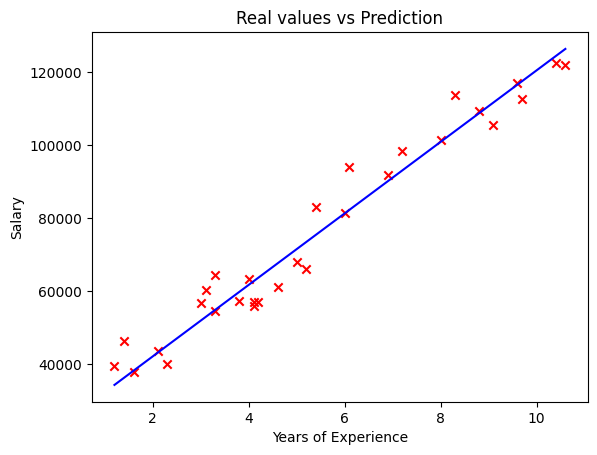

In [6]:
w_init = 0
b_init = 0
iters = 1000
l_rate = 0.011

w, b, Js, ws = gradient_descent(w_init, b_init, x_train, y_train, l_rate, iters)
print(f"found in grad descent | weight: {w} bias: {b} ")

plt.plot(range(0, iters, math.ceil(iters/10)), Js)
plt.xlabel("Iteration")
plt.ylabel("Cost J")
plt.title("Cost reduction over time")
plt.show()

plt.scatter(x_train, y_train, marker= "x", c="r")
y_predicts = w*x_train + b
plt.plot(x_train, y_predicts, c="b")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Real values vs Prediction")
plt.show()